# Education and Income Inequality
## Synthesis & Policy Discussion (Phase 07)

A cross-country panel analysis (1990-2023) of the relationship between mean
years of schooling and the Gini coefficient. This notebook integrates the
descriptive (Phase 03), typological (Phase 04), econometric (Phase 05), and
predictive / SHAP (Phase 06) layers of the project into a single synthesis,
names the limits of what observational panel data can identify, and outlines
the credible identification strategies most directly motivated by the
project's internal evidence.

**Synthesis layer (Scope §7.4 — closing artefact).** All numeric claims
trace to Phase 03-06 anchors documented in `docs/phase_summaries/` and
`PROJECT_LOG.md`; this notebook performs no new estimation.

## 1. Executive summary

**The single substantively converged finding.** Across three independent
estimation strategies — Phase 05 panel-econometric Random Effects with
country-cluster heterogeneity, Phase 06 Random Forest with TreeSHAP
attribution, and Phase 06 XGBoost with TreeSHAP attribution — the
within-country slope of Gini on mean years of schooling is negative and of
similar magnitude in the middle-development / Kuznets-transition cluster
identified by Phase 04 K-means. The three estimates of the cluster-1 slope
are **−1.19** (Phase 05 RE Spec C, p = 0.010), **−1.92** (Phase 06 RF
SHAP-on-mys regression on the test set), and **−2.00** (Phase 06 XGB
SHAP-on-mys regression on the test set). The aggregate-level estimates
across the broader Gini-reporting sample (Phase 05 Pooled OLS / FE / RE:
−1.33 \*\*\* / −0.38 ns / −0.69 \*; Phase 06 Ridge / RF / XGB raw-scale
or signed SHAP: −1.42 / −1.13 / −1.06) align in direction with the
cluster-1 finding while reflecting the well-known between-vs-within
identification distinction.

**The single substantive caveat.** The chained finding is *not* a causal
estimate. The Phase 06 boundary-case holdout — Brazil, South Africa,
Mexico, and Argentina removed from training and evaluated as a
59-country-year out-of-sample set — produces test R² = **−2.4** and a
sign-flip of the mean signed SHAP for mean years of schooling on Brazil,
South Africa, and Mexico (positive, in the +1.62 to +2.46 range), opposite
to the in-sample attribution. This is the strongest internal evidence that
the in-sample SHAP attribution reflects within-distribution interpolation
rather than transportable causal structure. Section 6 generalises this
finding to four threats to identification; Section 7 outlines the credible
identification strategies a follow-on study would require.

In [ ]:
import pandas as pd
import sys
from pathlib import Path
from IPython.display import Image

# Locate project root (works whether the notebook is run from the
# notebooks/ directory or from project root via nbconvert).
_HERE = Path.cwd()
for _candidate in [_HERE, *_HERE.parents]:
    if (_candidate / "src" / "paths.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from src.paths import find_project_root

PROJECT_ROOT = find_project_root()

# The synthesis table is the canonical Phase 07 cross-method anchor
# (Step 02 output). All numeric claims in this notebook trace to it
# or to the per-phase summary documents.
synthesis = pd.read_csv(
    PROJECT_ROOT / "outputs" / "tables" / "phase07_s02_synthesis_table.csv",
    dtype={"phase": str, "estimator": str, "scope": str, "source_artefact": str},
)

# Display the Cluster 1 chained finding -- the project headline.
cluster_1 = synthesis[synthesis["scope"] == "cluster_1"].copy()
cluster_1[["phase", "estimator", "mys_effect", "ci_lower", "ci_upper", "p", "n"]].reset_index(drop=True)

,phase,estimator,mys_effect,ci_lower,ci_upper,p,n
0,05,re_spec_c_within_country,-1.19,-2.09,-0.28,0.01,NaN
1,06,rf_shap_on_mys_slope,-1.92,NaN,NaN,NaN,105.0
2,06,xgb_shap_on_mys_slope,-2.00,NaN,NaN,NaN,105.0


### 1.1 The aggregate convergence figure

Figure 1 places the seven aggregate-scope mys estimates from Phases 03-06
on a single x-axis. All seven point estimates are negative; six of seven
sit in the band roughly −0.4 to −1.4 Gini-points per mys-year, with
Phase 03 Pearson r (which is on a different unit scale) at −0.52. The
Phase 05 95 % confidence intervals make the within-vs-between
identification structure visible: Pooled OLS and RE both have intervals
strictly below zero, while two-way FE has an interval that crosses zero
(p = 0.366), reflecting the loss of statistical precision when only
within-country variation is identified.

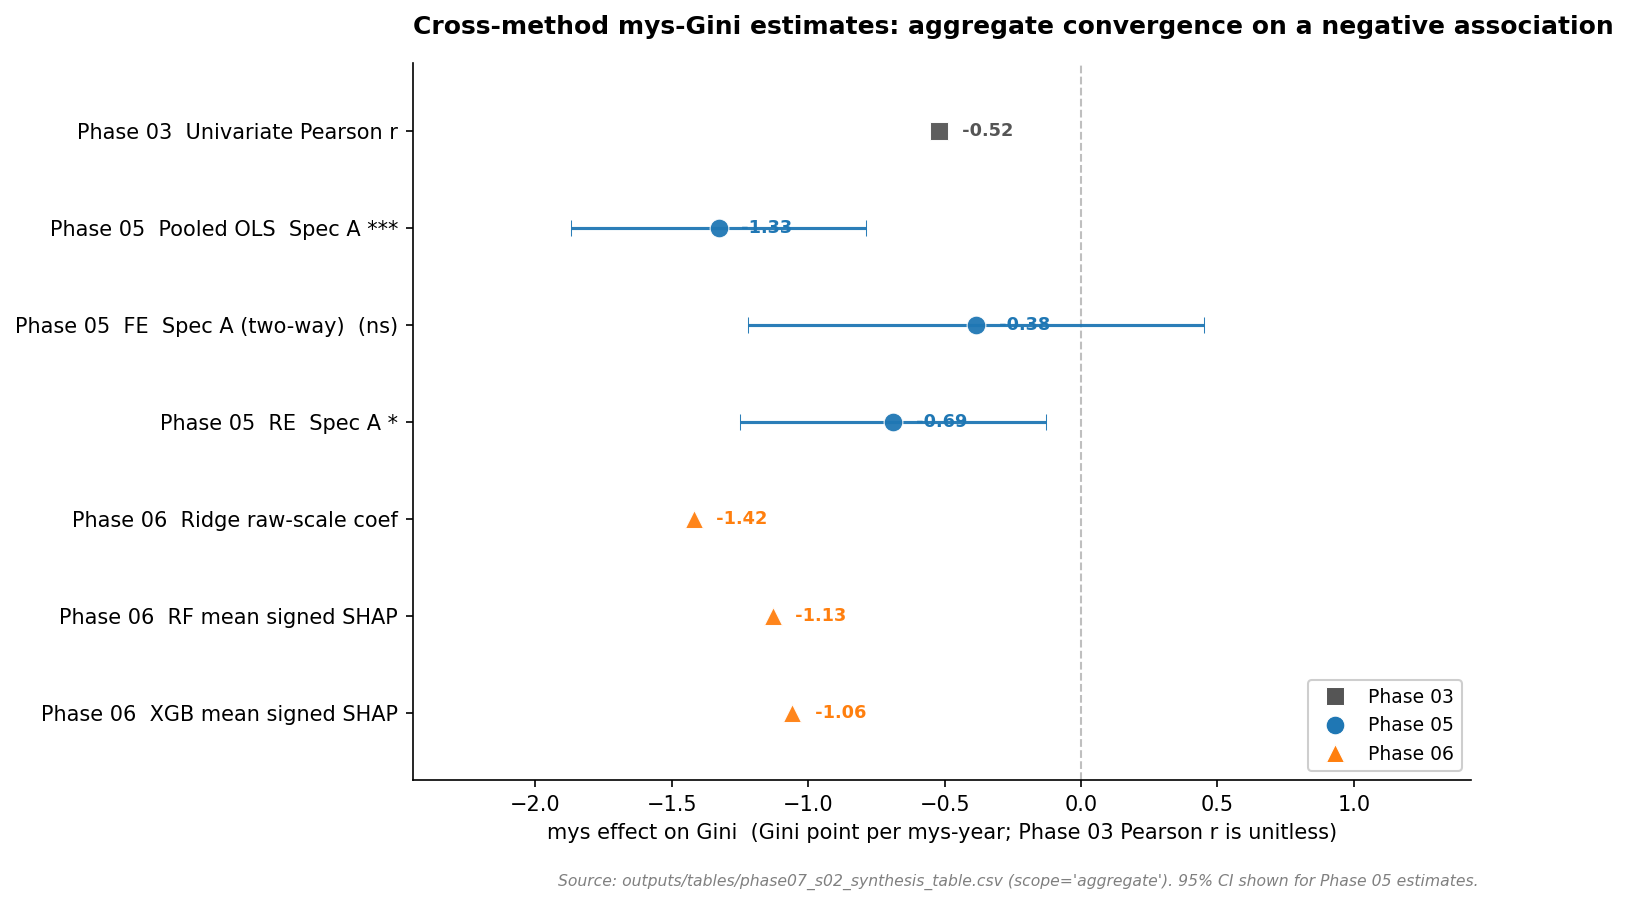

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase07_s03_convergence.png"))

### 1.2 The single most important caveat

The convergence shown in Figure 1 is association, not causation. Section 6
elaborates the four threats to causal identification (omitted variables,
reverse causality, measurement error, and selection bias from
Gini-reporting). The single most consequential piece of internal evidence
against a causal reading is the Phase 06 boundary-case holdout result
described in §6.3.

### 1.3 Roadmap

The remainder of this notebook walks the analytical chain that produced the
headline finding (§§2-5: descriptive → typological → econometric →
predictive / SHAP), then turns to the three synthesis-layer questions that
Phase 07 was designed to answer:

- **§6** — Why is the convergent finding not yet causal?
- **§7** — What credible identification strategies would convert it into a
  causal estimate?
- **§8** — What policy implications, *conditional* on a causal reading,
  follow for Cluster 1?
- **§9** — What are the structural limitations of the analysis, and what
  is the research agenda that would address them?

## 2. Phase 03 — Descriptive baseline

**Observation.** Among nineteen variables in the analytical panel, mean
years of schooling has the strongest single-regressor linear association
with Gini: Pearson r = **−0.52** and a univariate OLS R² of **0.27**. The
next-strongest predictors (log GDP per capita PPP, urban population share,
secondary enrolment) have similar but slightly weaker bivariate associations.

**Explanation.** The dominance of mean years of schooling in the bivariate
baseline is consistent with the intuition that educational attainment is a
comparatively stable, comprehensive summary of human-capital stock —
closer to a structural characteristic of a country than to a flow variable
like enrolment or expenditure. The substantive headline of Phase 03 — that
the candidate predictors trace a Kuznets-type inverted-U pattern when
arrayed against income group — is reproduced in independent form by
Phase 04 K-means without using Gini as a clustering input.

**Implication for later phases.** The bivariate result motivates Phase 05
Spec A's inclusion of mean years of schooling as the principal regressor.
The Phase 03 VIF screen also motivates Phase 05's choice of `enrol_secondary`
as the single representative of the secondary-enrolment trio (the three
enrolment variables are arithmetically nested with VIFs in the 9,000-40,000
range, forcing a one-of-three choice).

### 2.1 The multicollinearity discipline imposed by Phase 03

Phase 03's VIF analysis isolated three structural multicollinearity blocks:
the secondary-enrolment trio (primary / secondary / tertiary enrolment,
jointly nested by definition), the GDP duo (PPP and USD measures, both
VIF > 10), and the sector-share trio (agriculture / manufacturing /
services, jointly summing to 100 %). Phase 05 Spec A inherits the three
resolutions: pick `enrol_secondary` from the enrolment trio, pick
`log(gdp_per_capita_ppp)` from the GDP duo (PPP is more
cross-country-comparable), and the sector trio is jointly usable in Spec B
(VIF agri 5.4 / services 2.9 / manu 1.4 — large but jointly identifiable).

Without these resolutions, the Spec A baseline coefficient on mean years of
schooling would be unstable across reasonable specification choices. The
downstream implication is that the −1.328 \*\*\* Pooled OLS Spec A
coefficient (Section 4) is a coefficient on mean years of schooling
*holding constant a single representative of the enrolment block, the
PPP-GDP measure, and the structural controls* — not a coefficient that
survives any multicollinearity-tolerant specification chosen at random.

## 3. Phase 04 — Country typology

**Observation.** K-means clustering on a seven-feature country-level matrix
(mean years of schooling, log GDP per capita PPP, secondary enrolment,
three sector shares, urban population share — *not* Gini) produces three
clusters with the following profiles:

| Cluster | Label | n | Mean Gini | Mean mys | Mean log(gdp_ppp) |
|---:|---|---:|---:|---:|---:|
| 0 | Low-development / SSA-led | 40 | 38.24 | 4.22 | 8.09 (~$3,246) |
| 1 | Middle-development / Kuznets transition | **59** | **39.05** | **8.85** | 9.37 (~$11,678) |
| 2 | High-development / mature economies | 68 | 34.72 | 11.36 | 10.60 (~$40,223) |

The 50 countries with insufficient feature coverage in the 2010-2019
aggregation window are excluded by listwise drop (Phase 04 §Known Issues).
**167 of 217 countries are clustered.**

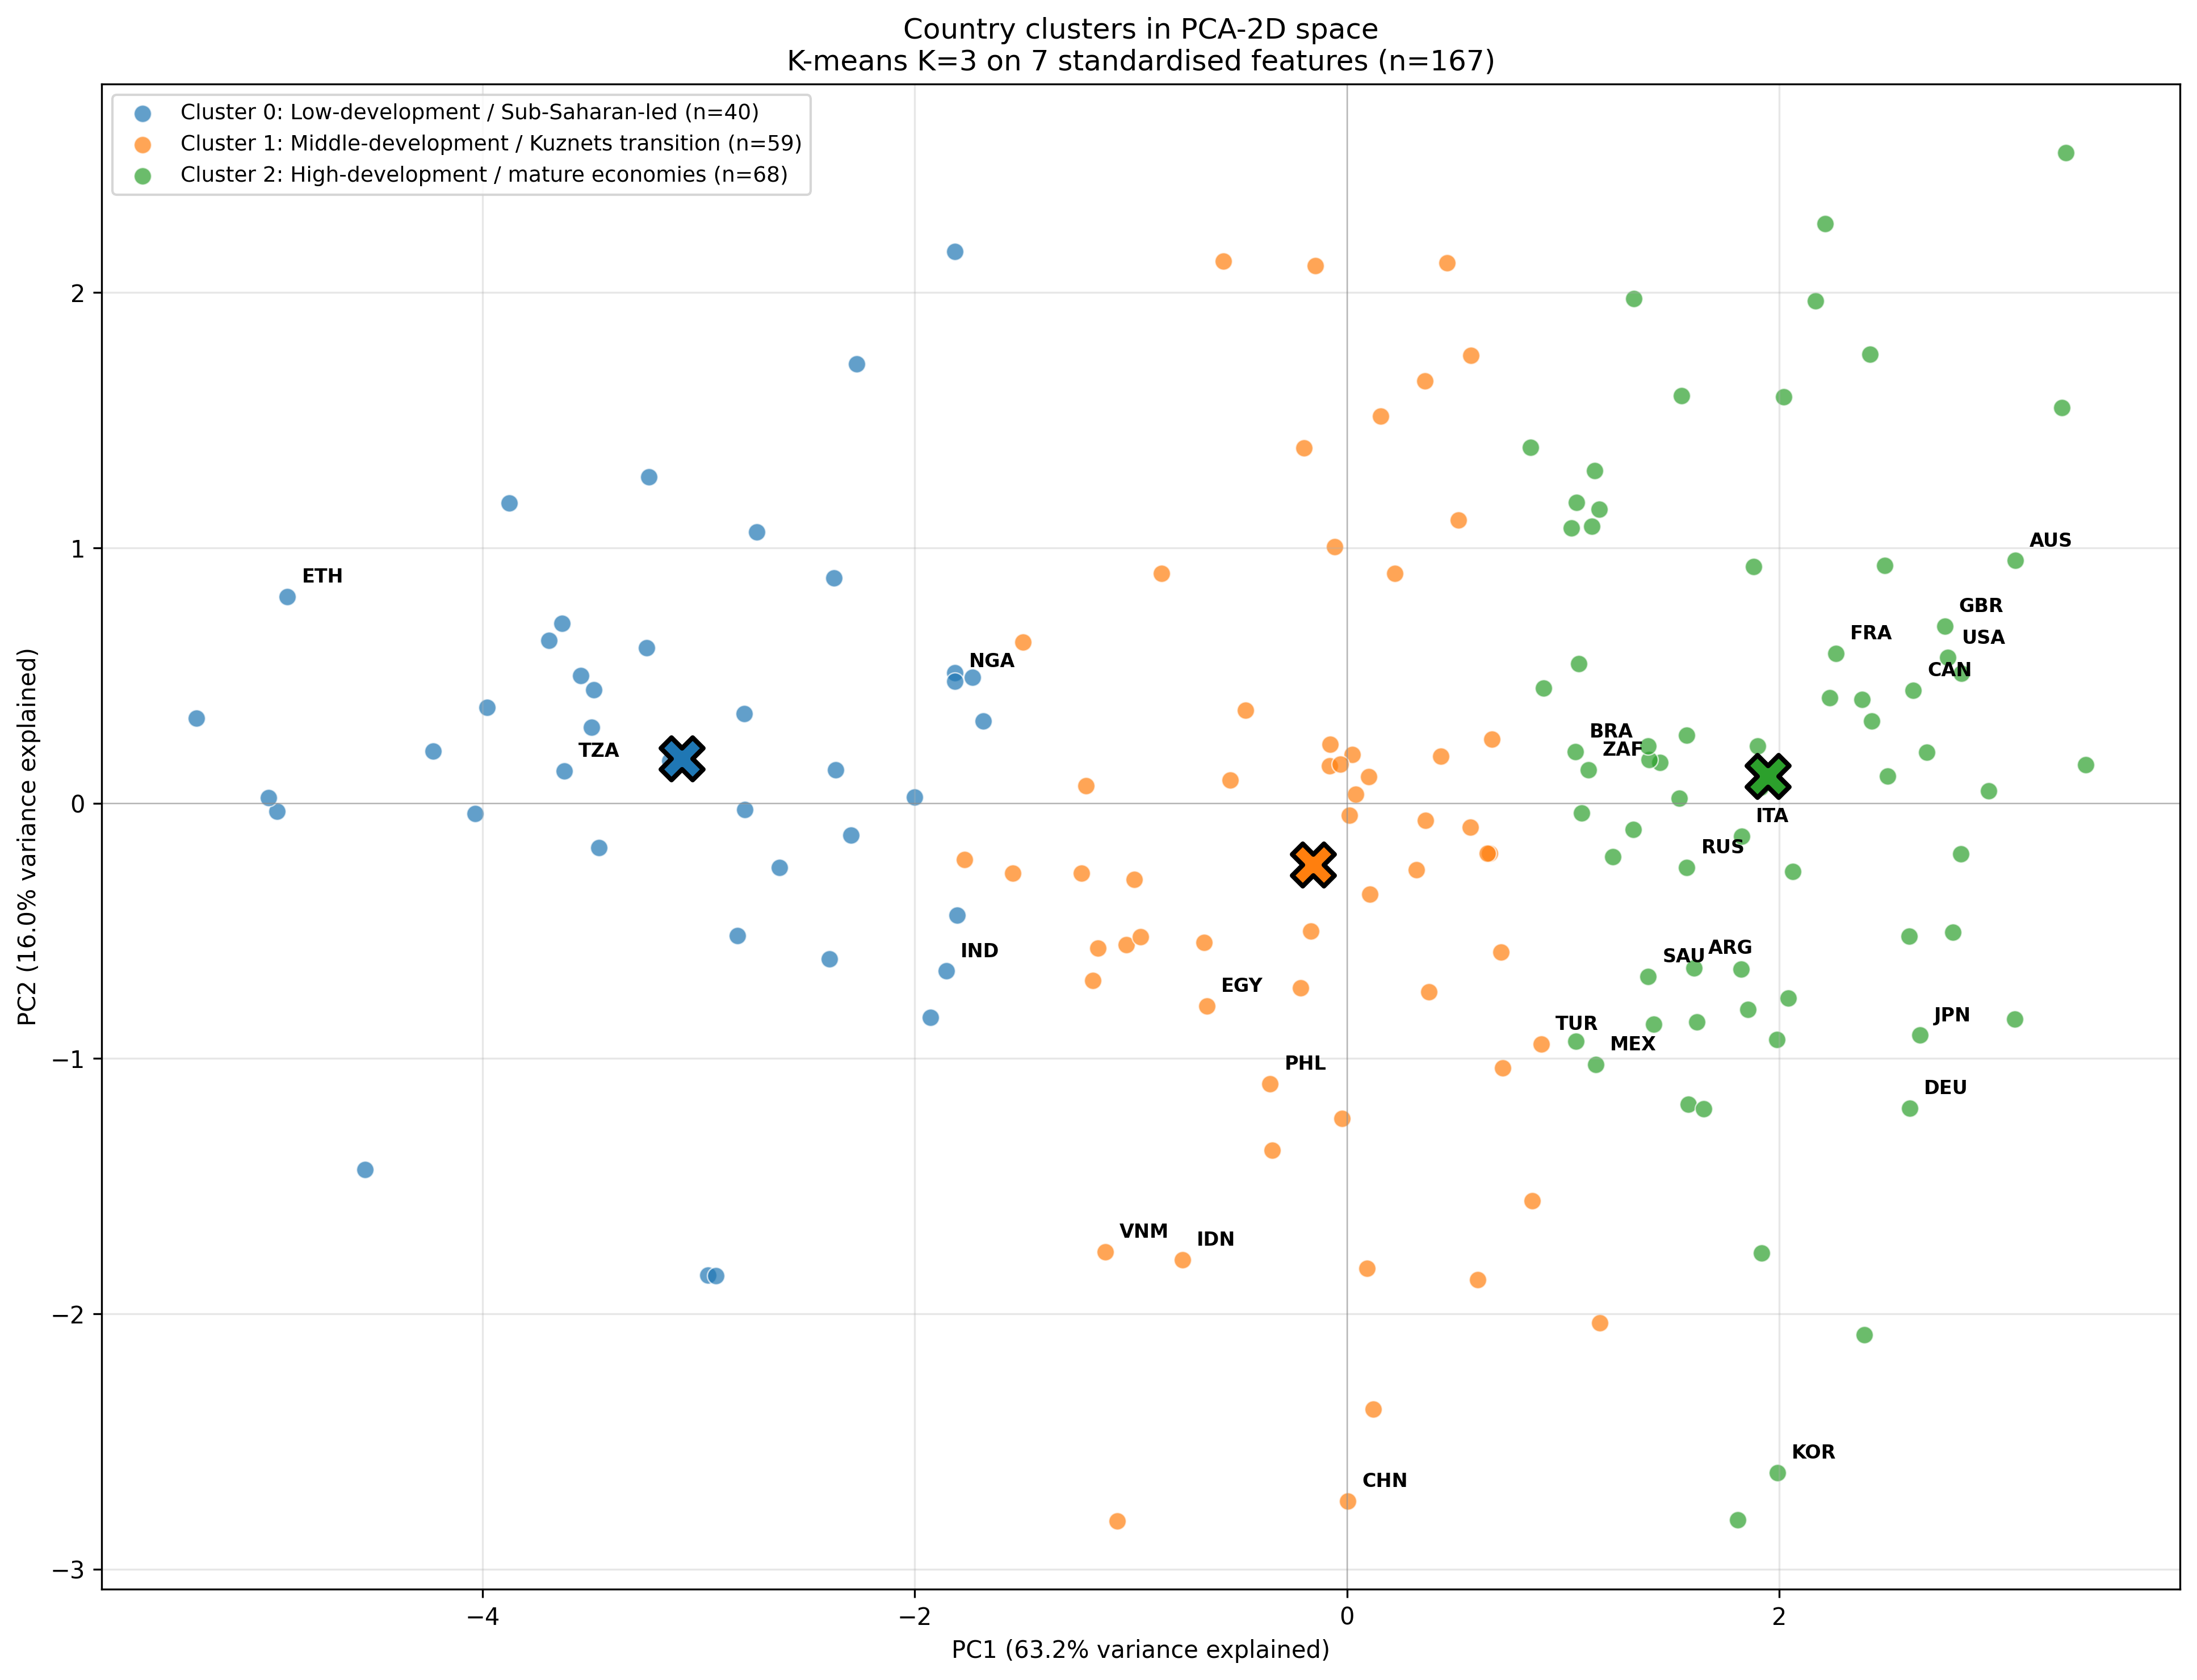

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase04_s06_pca_scatter.png"))

**Explanation.** The cluster typology has two structural properties that
shape the rest of the project. First, the development gradient is
approximately one-dimensional in the seven-feature space: PC1 captures
**63.2 %** of the cross-country variance, with PC1 + PC2 reaching 79.2 %.
The seven features are not seven independent axes but seven correlated
indicators of a single underlying development dimension. Second, the
clustering — which did *not* use Gini as an input — independently
re-discovers a Kuznets-type pattern: Cluster 1 (the middle group) has the
highest mean Gini at 39.05, exceeding both Cluster 0 (38.24, low-development)
and Cluster 2 (34.72, mature). This is independent
same-finding-two-different-ways evidence for the inverted-U pattern noted
in Phase 03's income-group view.

**Implication.** Cluster 1 — *not* the lowest-development cluster — is the
regime in which the education-inequality relationship deserves the highest
analytical priority. The other two clusters represent the inverted-U's
flanks: Cluster 0 is below the threshold where schooling expansion has
begun in earnest, while Cluster 2 is at or near saturation. The chained
finding documented in §1 is concentrated specifically in Cluster 1; this
is structural, not coincidental.

## 4. Phase 05 — Econometric panel estimation

**Observation — the tri-headline reconciliation.** Phase 05 estimated three
panel specifications on the Spec A canonical sample of **1,642
country-years from 153 countries**, with country-clustered standard errors
throughout:

| Estimator | mys coefficient (Spec A) | SE | p | 95 % CI | Identification |
|---|---:|---:|---:|---|---|
| Pooled OLS | **−1.328 \*\*\*** | 0.275 | < 0.001 | [−1.87, −0.79] | Cross-country (between) |
| Two-way FE | −0.384 | 0.425 | 0.366 | [−1.22, +0.45] | Within-country only |
| RE | **−0.688 \*** | 0.285 | 0.016 | [−1.25, −0.13] | GLS-combined (θ = 0.82) |

The three estimators are reporting different aggregations of the same
evidence. Pooled OLS identifies the negative association from the dominant
between-country variation; Two-way FE strips that variation out and is
left with a noisy null at the within-country level; RE recovers an
intermediate value via a θ = 0.82 GLS combination heavily weighted toward
the FE end.

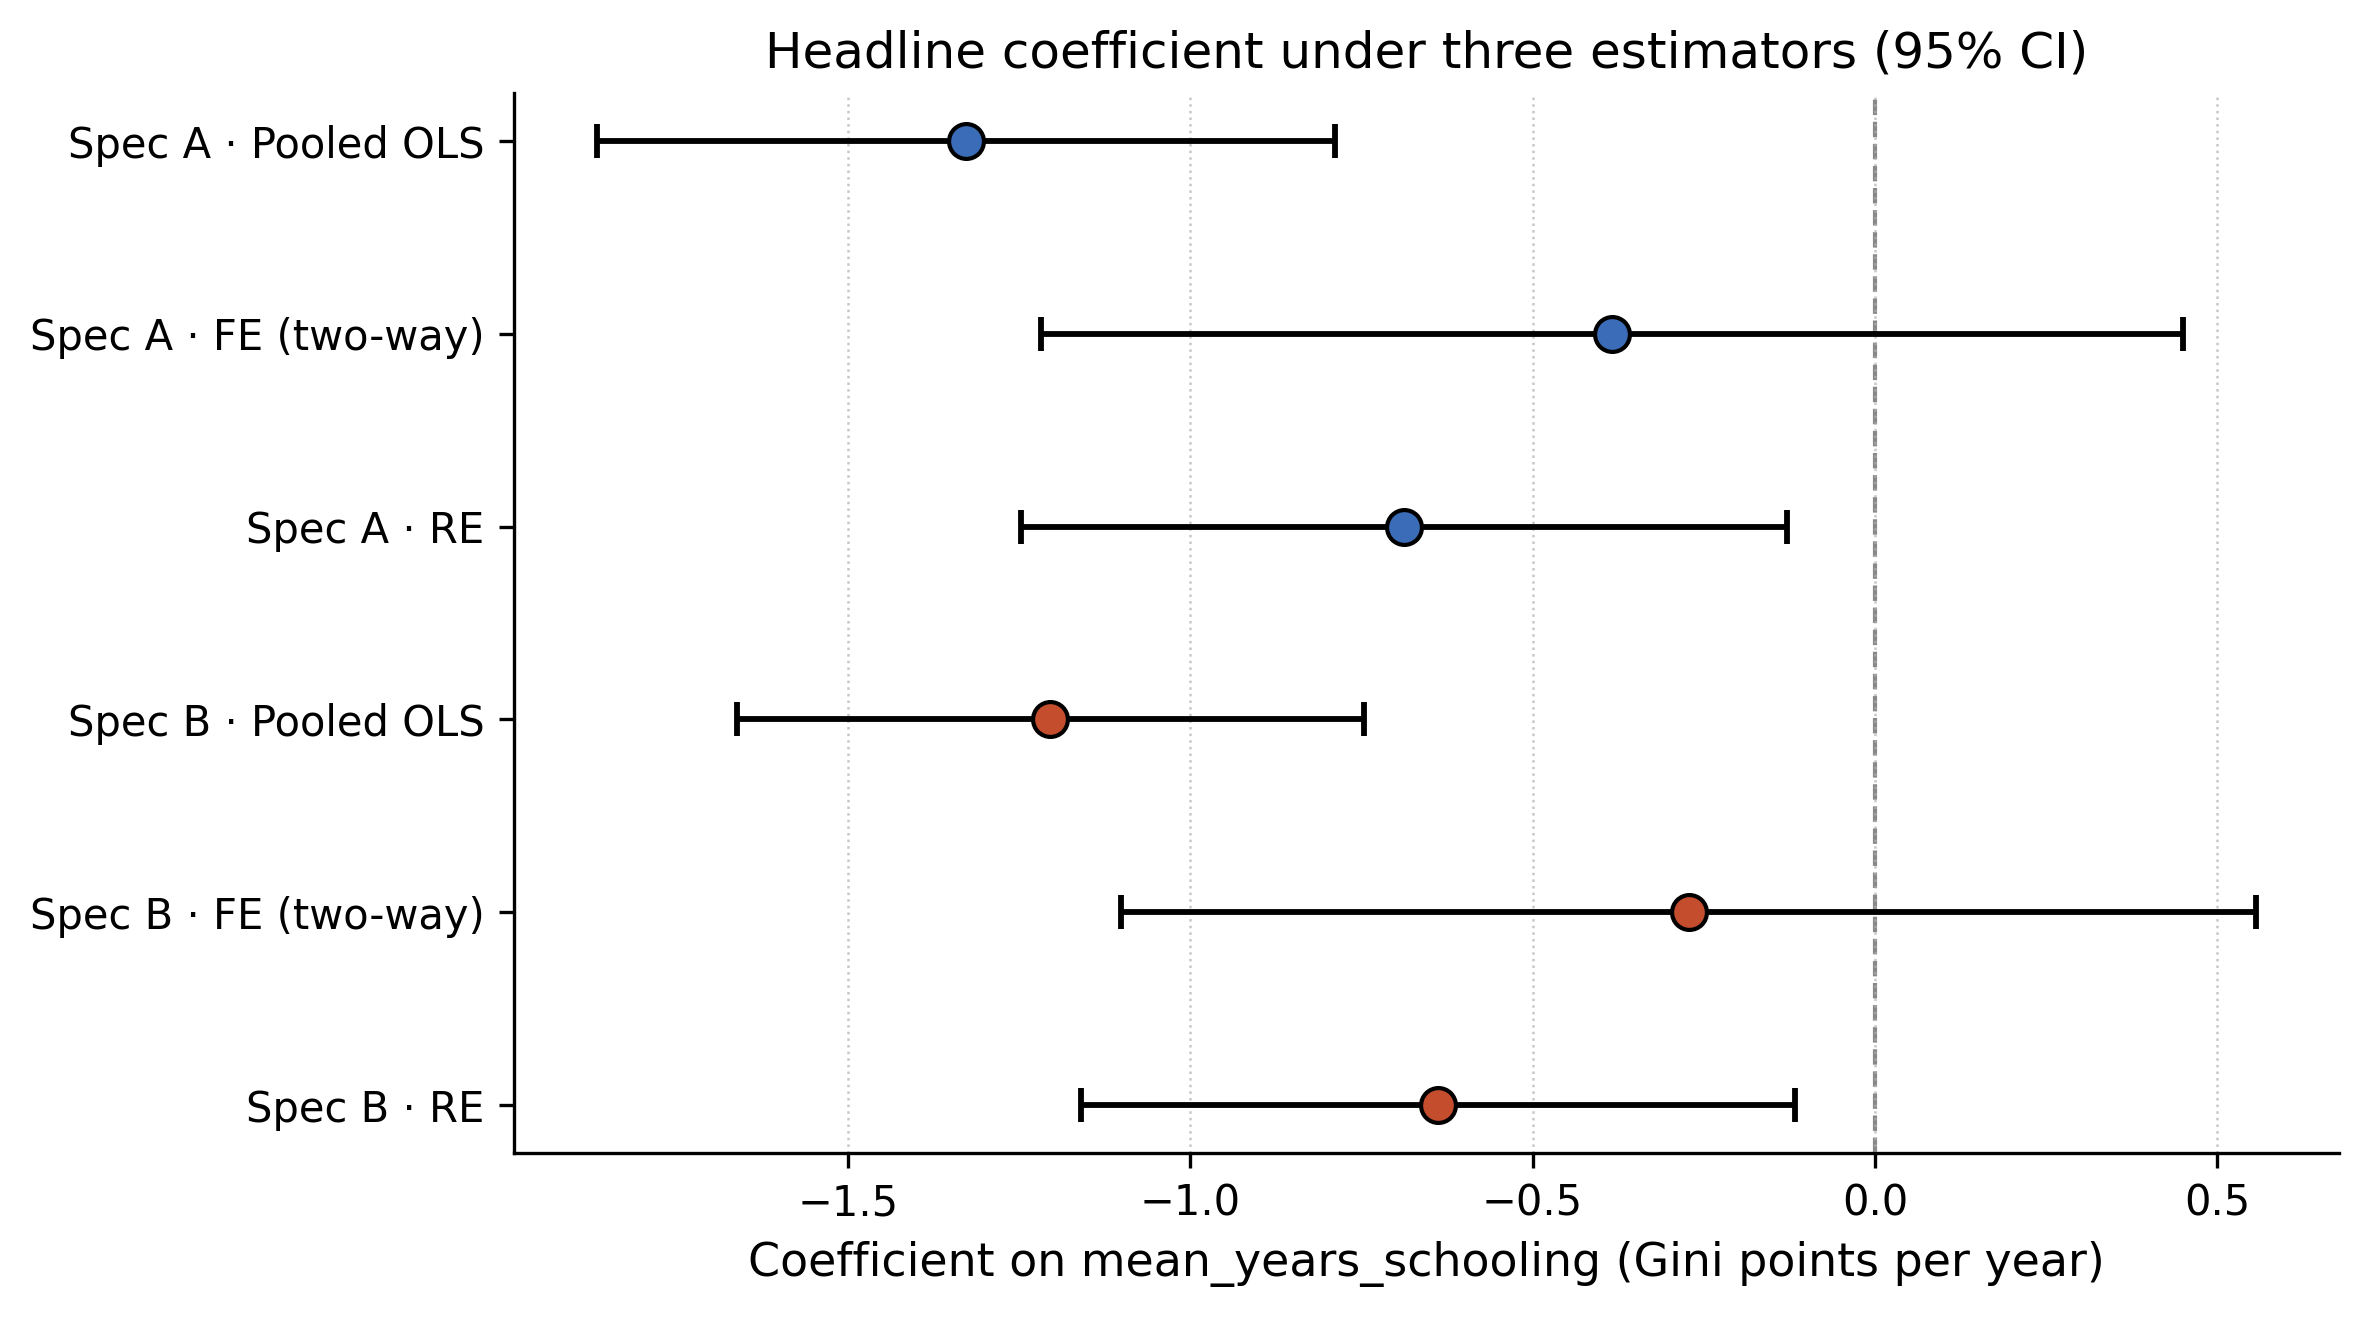

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase05_s08_forest_plot.png"))

**Explanation — why the three are not a "pick the best" problem.** The
Phase 05 Step 07 robustness checks revealed a Mundlak-Hausman conflict:
Spec A Hausman p = 0.402 fails to reject Random Effects, but Spec B
Mundlak Wald p < 0.0001 strongly rejects RE in favour of FE. Under
cluster-robust standard errors in panels of moderate cluster count (around
140-150), Hausman is numerically unstable, and the conflict cannot be
resolved at this layer. Step 07b documented an adaptive override: rather
than promote any single estimator's coefficient as the headline, Phase 05
reports the three in parallel and treats the reconciliation pattern
(strong Pooled OLS → null FE → intermediate RE) as the primary aggregate
finding. The three-estimator parallel reporting itself is the deliverable
of the aggregate layer, not a step toward picking one.

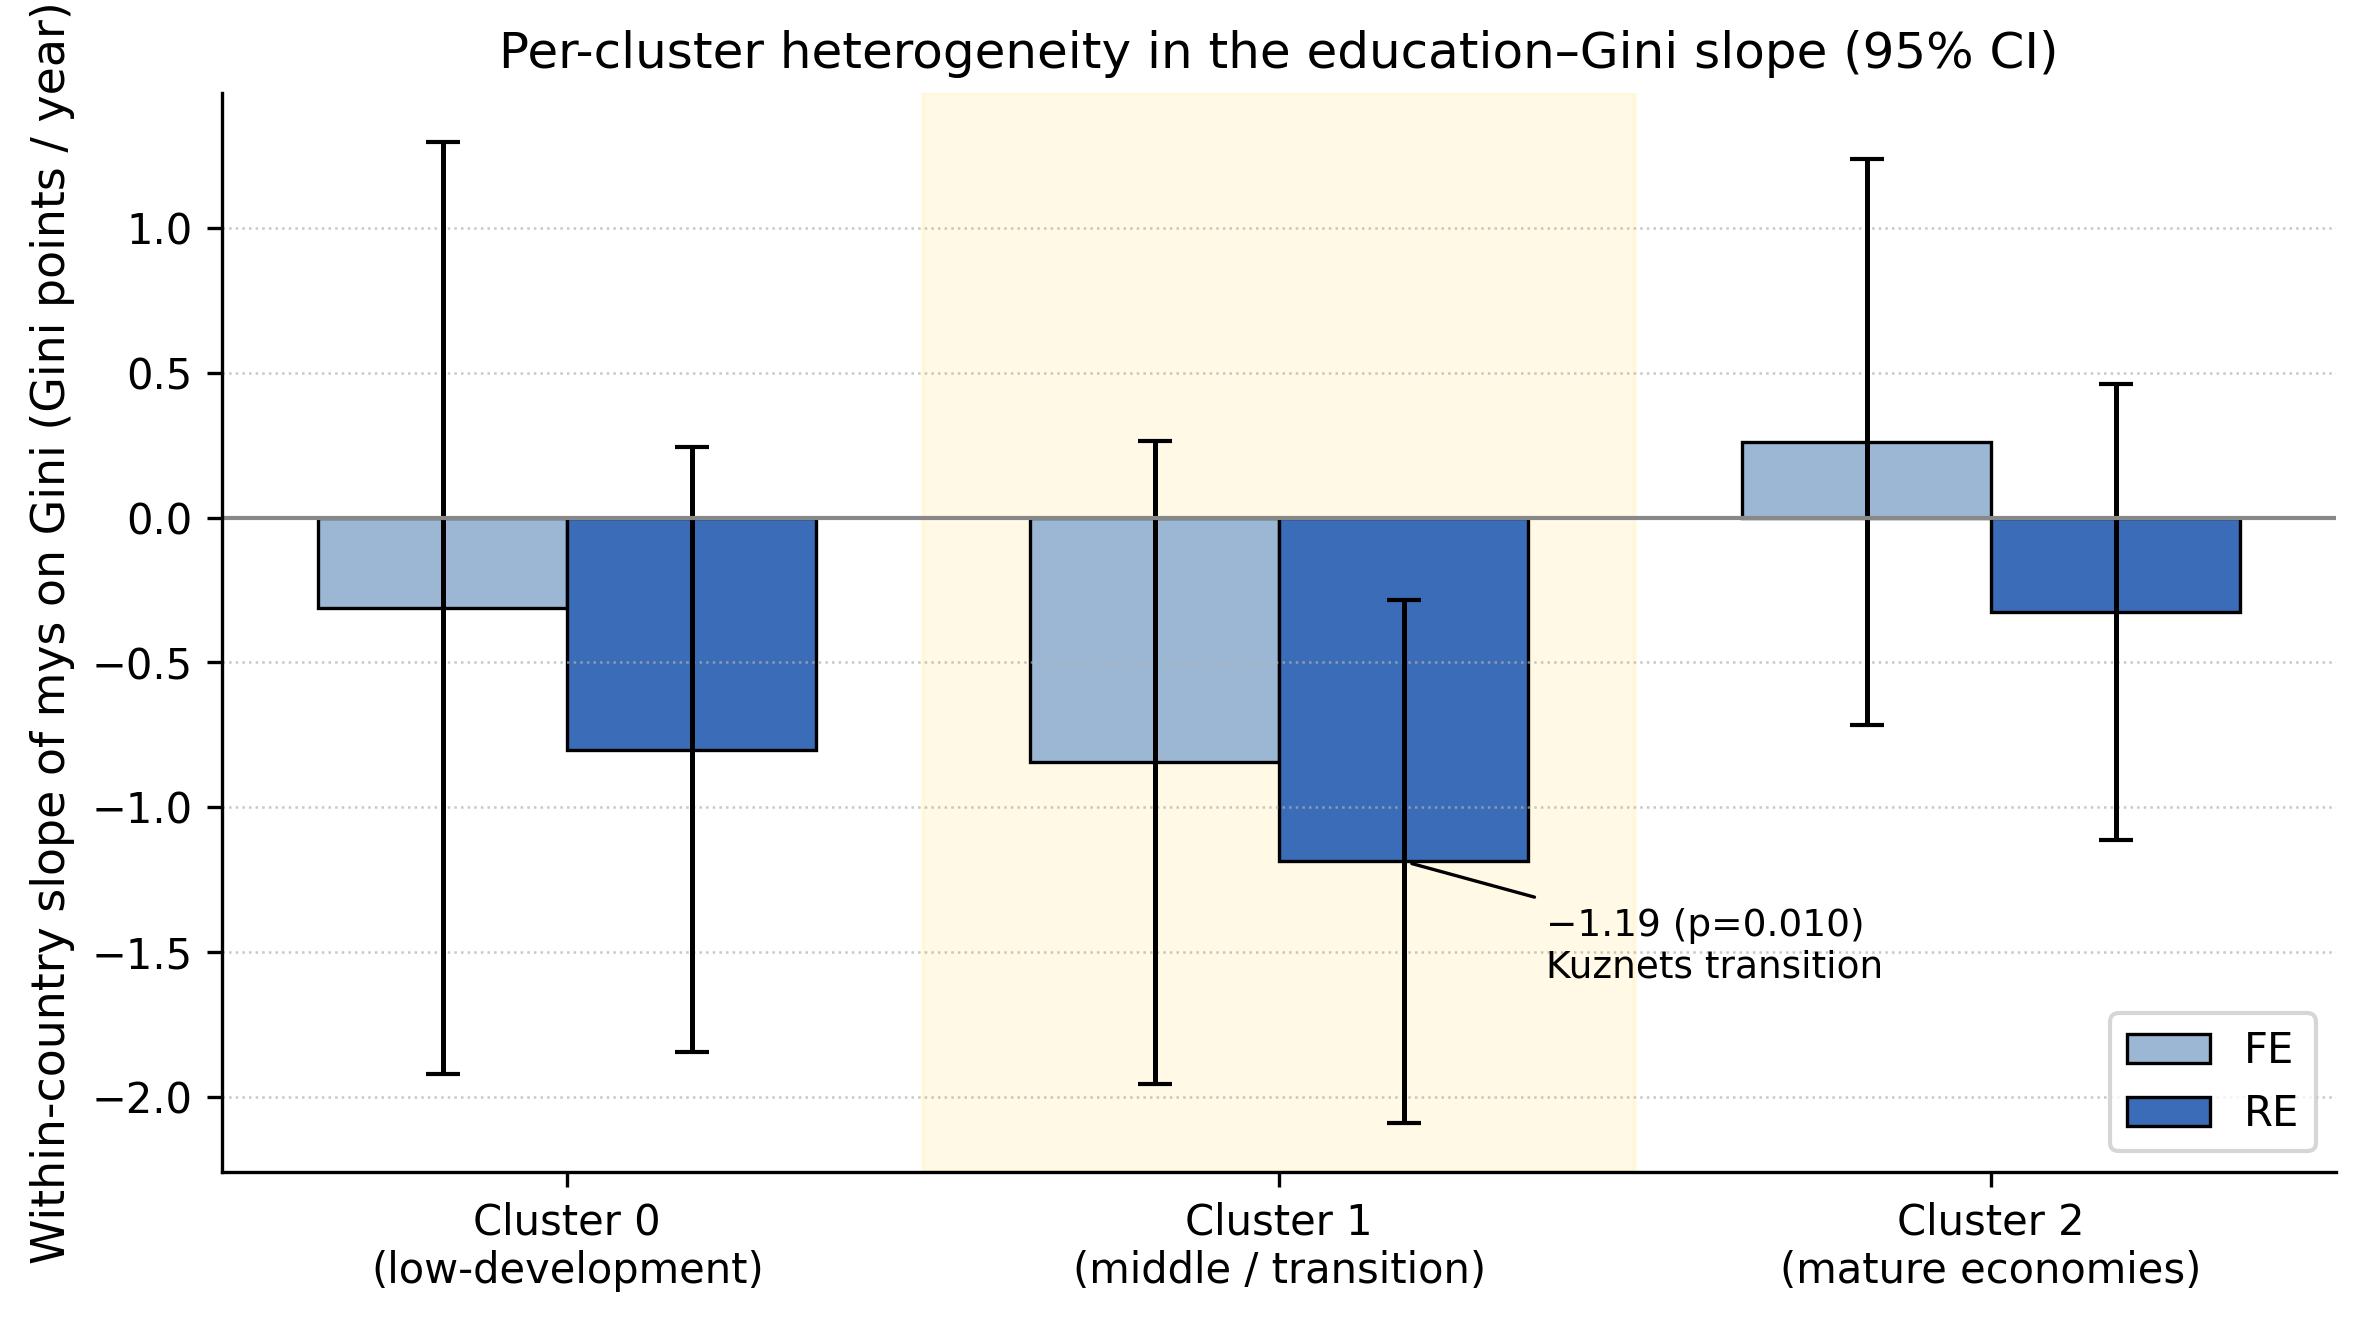

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase05_s08_cluster_slopes.png"))

**Observation — the Cluster 1 heterogeneity finding.** Spec C extends Spec
A with a `mys × cluster_kmeans_k3` interaction. Computing per-cluster
within-country slopes from the RE Spec C parameter covariance via the
delta method:

| Cluster | RE Spec C within-country slope | p | Note |
|---|---:|---:|---|
| 0 (low-development) | −0.80 | 0.13 | Insufficient mys variation to identify (mean mys 4.22) |
| 1 (Kuznets transition) | **−1.19 \*** | **0.010** | The headline cluster-specific finding (95 % CI [−2.09, −0.28]) |
| 2 (mature economies) | −0.33 | 0.42 | Schooling near-saturated (mean mys 11.36) |

Boundary-case reassignment (BRA / ZAF / MEX / ARG → Cluster 1, sensitivity
to algorithm-induced cluster boundaries): Cluster 1 RE slope shifts to
−1.15 (p = 0.008). The finding is robust to the K-means / Ward clustering
uncertainty (Phase 04 ARI = 0.65) and to the 4-country reassignment
perturbation.

**Implication.** The aggregate FE null is consistent with a non-zero
Cluster 1 within-country slope masked by zero or weak slopes in Clusters 0
and 2. The aggregate FE result (−0.38, ns) is the population-weighted
average of the three cluster slopes; arithmetically, the Cluster 1 finding
survives because the cluster-specific identification is not subject to the
same averaging-out. The Cluster 1 within-country slope of −1.19 is the
substantive contribution of the Phase 05 explanatory layer beyond the
descriptive findings of Phase 03 / 04, and it is the first of the three
estimates that compose the chained finding documented in §1.

## 5. Phase 06 — Predictive modelling and SHAP attribution

**Observation — the predictive ladder.** Three models (Ridge with one-hot
cluster encoding; Random Forest; XGBoost) trained on the Phase 05 Spec A
canonical sample under TimeSeriesSplit cross-validation produce the
following test-set performance:

| Model | Train R² | Test R² | TSS CV RMSE | Random KFold CV RMSE | TSS−RKF gap |
|---|---:|---:|---:|---:|---:|
| Ridge | 0.524 | 0.426 | 5.91 | 6.02 | −0.11 |
| Random Forest | 0.979 | **0.706** | 3.94 | 3.53 | +0.41 |
| XGBoost | 0.999 | **0.733** | 3.94 | 3.34 | +0.60 |

The Ridge → Random Forest gap of +0.28 in test R² is the non-linear and
interaction-driven component of the signal that linear panel models cannot
capture. The widening TimeSeriesSplit-minus-random-KFold gap with model
flexibility reflects the structural temporal-extrapolation cost on panel
data — random KFold lets training and validation share adjacent years,
while TimeSeriesSplit forces strictly future-out-of-sample evaluation.

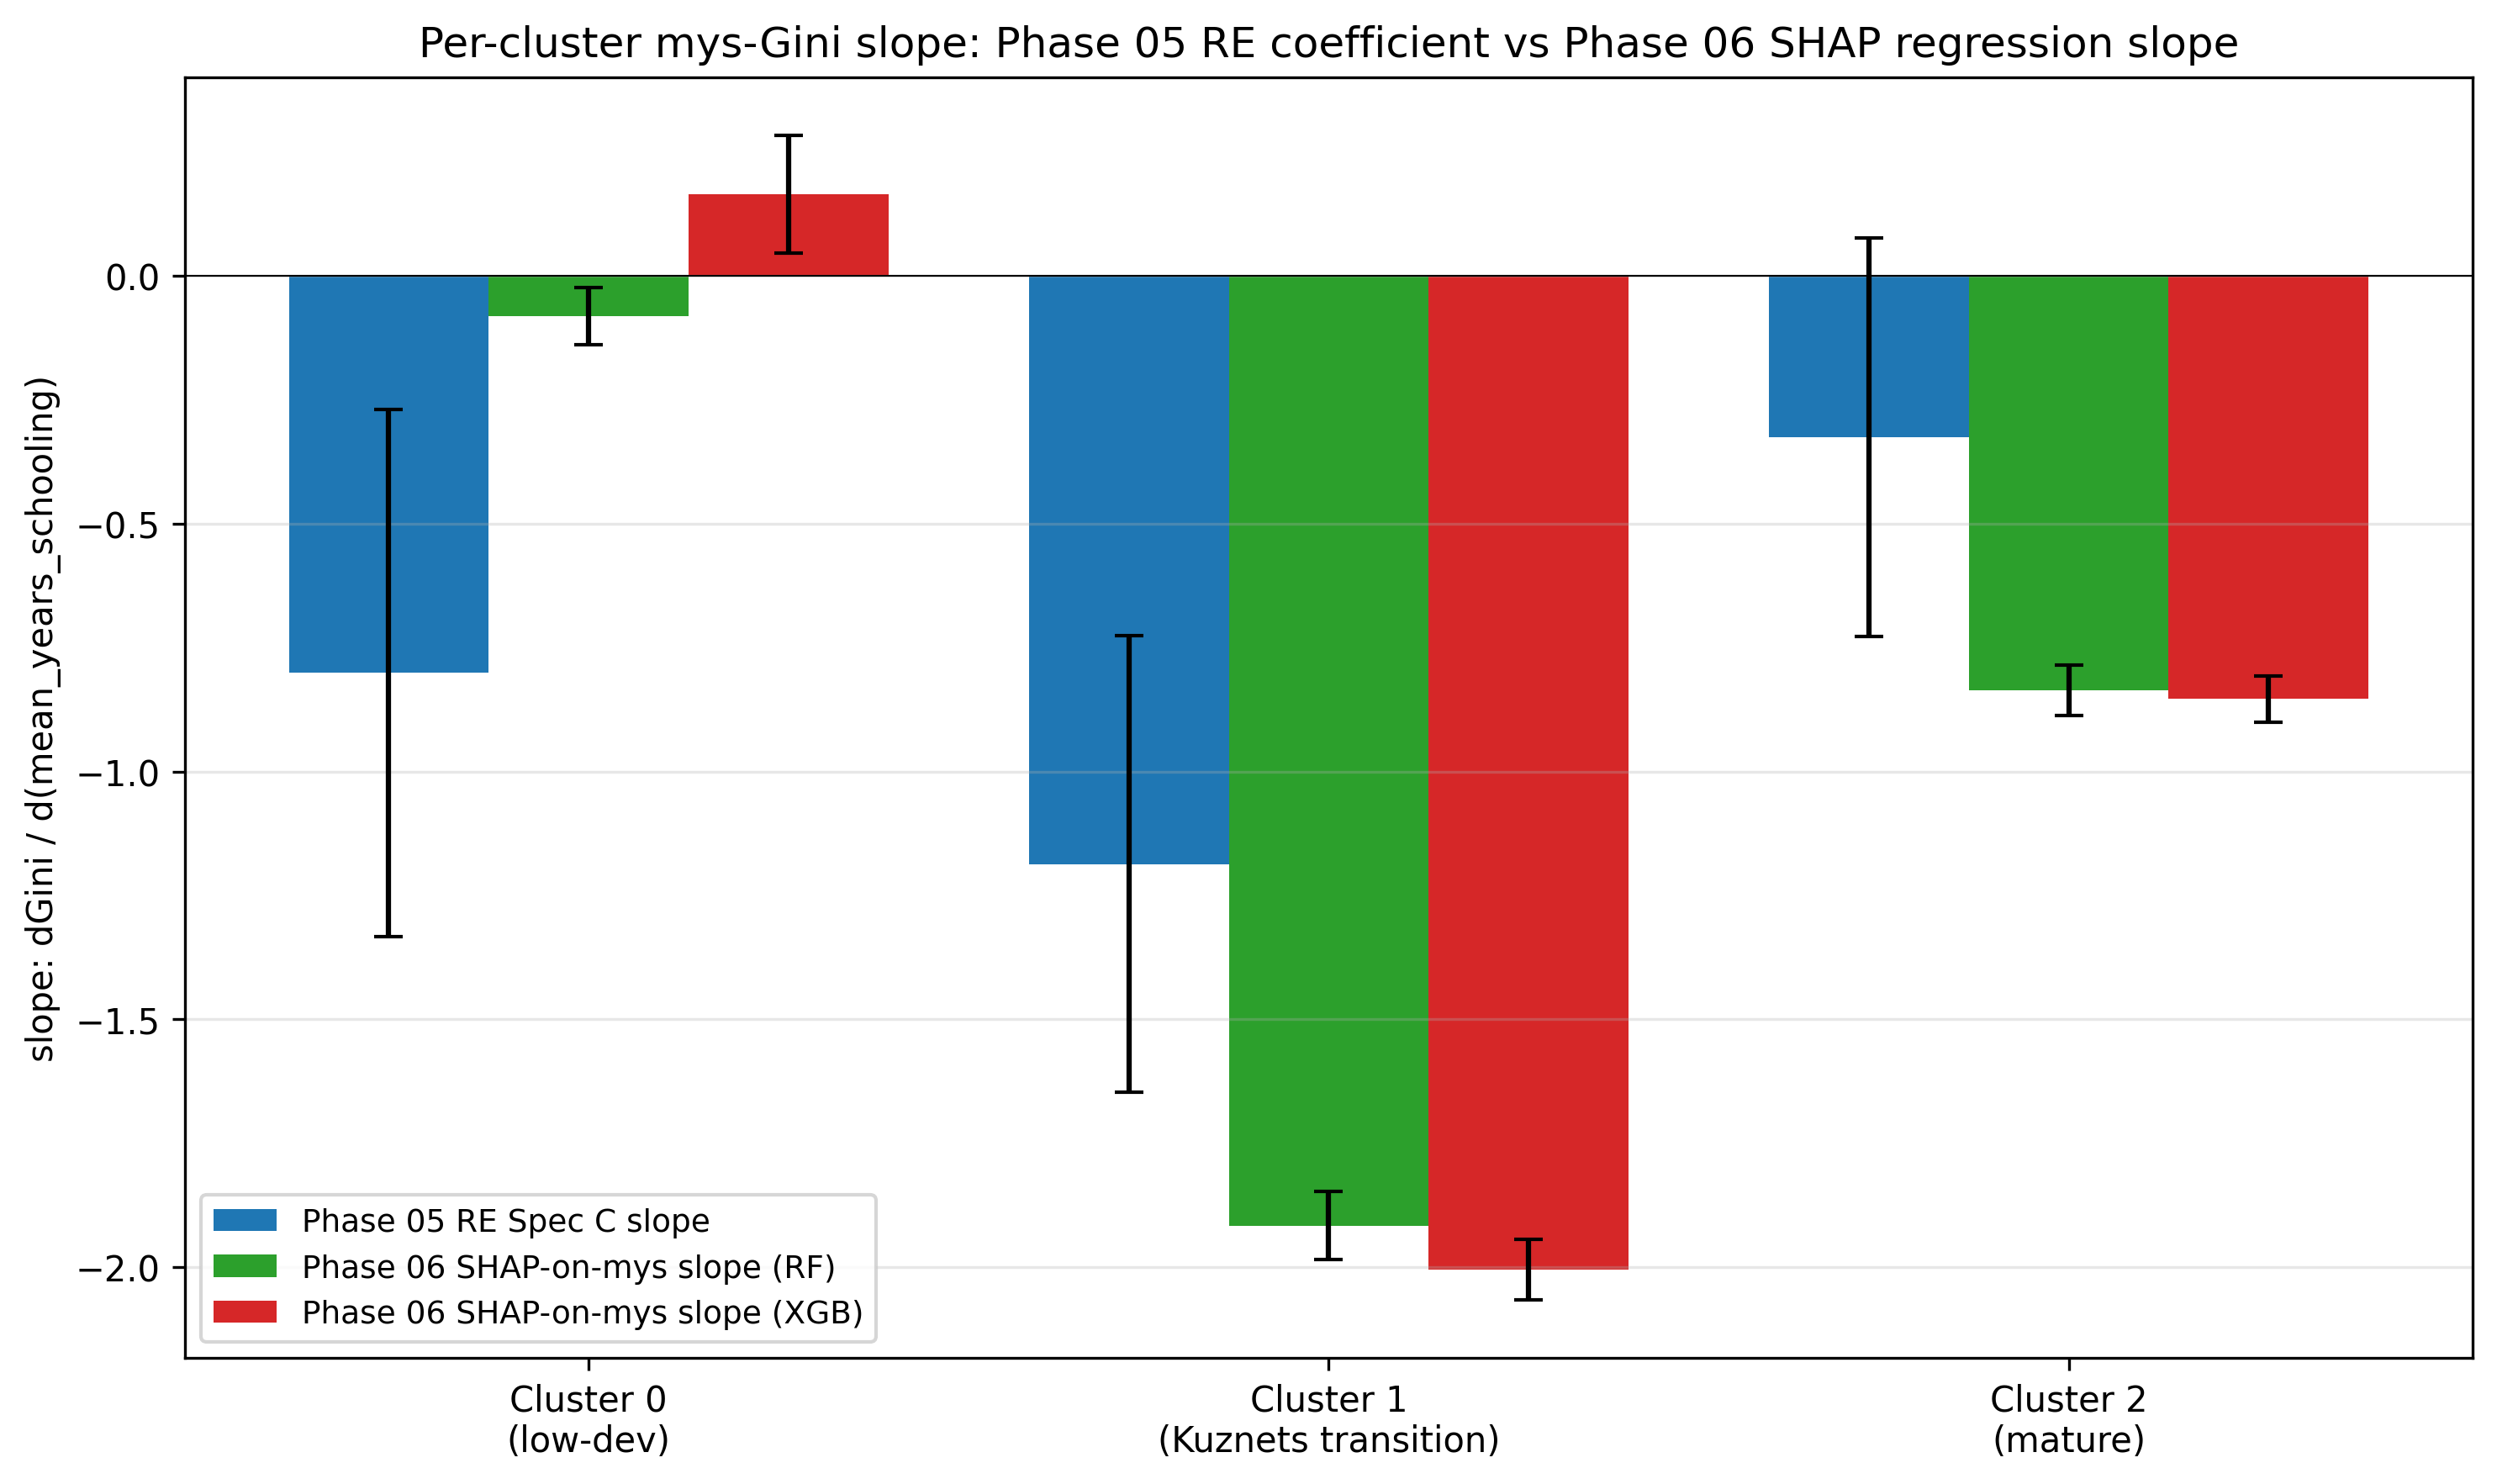

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase06_s07_per_cluster_slopes.png"))

**Observation — the per-cluster SHAP-on-mys finding.** Both Random Forest
and XGBoost produce **identical top-5 global SHAP rankings** (mean years
of schooling, log GDP per capita PPP, secondary enrolment, trade openness,
government expenditure / GDP). Mean signed SHAP for mys is **−1.13** (RF)
and **−1.06** (XGB) on the test set, close to Phase 05 Pooled OLS (−1.33)
and Phase 06 Ridge raw-scale (−1.42), and well above Phase 05 FE (−0.38).
ML estimates a mixed-identification quantity, not a strict within-country
quantity.

Regressing the per-row signed SHAP values for mys on the per-row mys
values within each test-set cluster produces local marginal-effect
estimates:

| Cluster | RF SHAP-on-mys slope | XGB SHAP-on-mys slope | Phase 05 RE Spec C comparison |
|---|---:|---:|---:|
| 0 (low-dev, n=17) | −0.08 | +0.16 | −0.80 (ns) |
| 1 (Kuznets, n=105) | **−1.92** | **−2.00** | −1.19 \*\* |
| 2 (mature, n=188) | −0.84 | −0.85 | −0.33 (ns) |

Phase 06 corroborates the Phase 05 Cluster 1 finding and *strengthens* it:
the local marginal effect at the test-set SHAP-on-mys regression slope is
roughly **1.7 ×** the Phase 05 RE Spec C linear panel estimate.

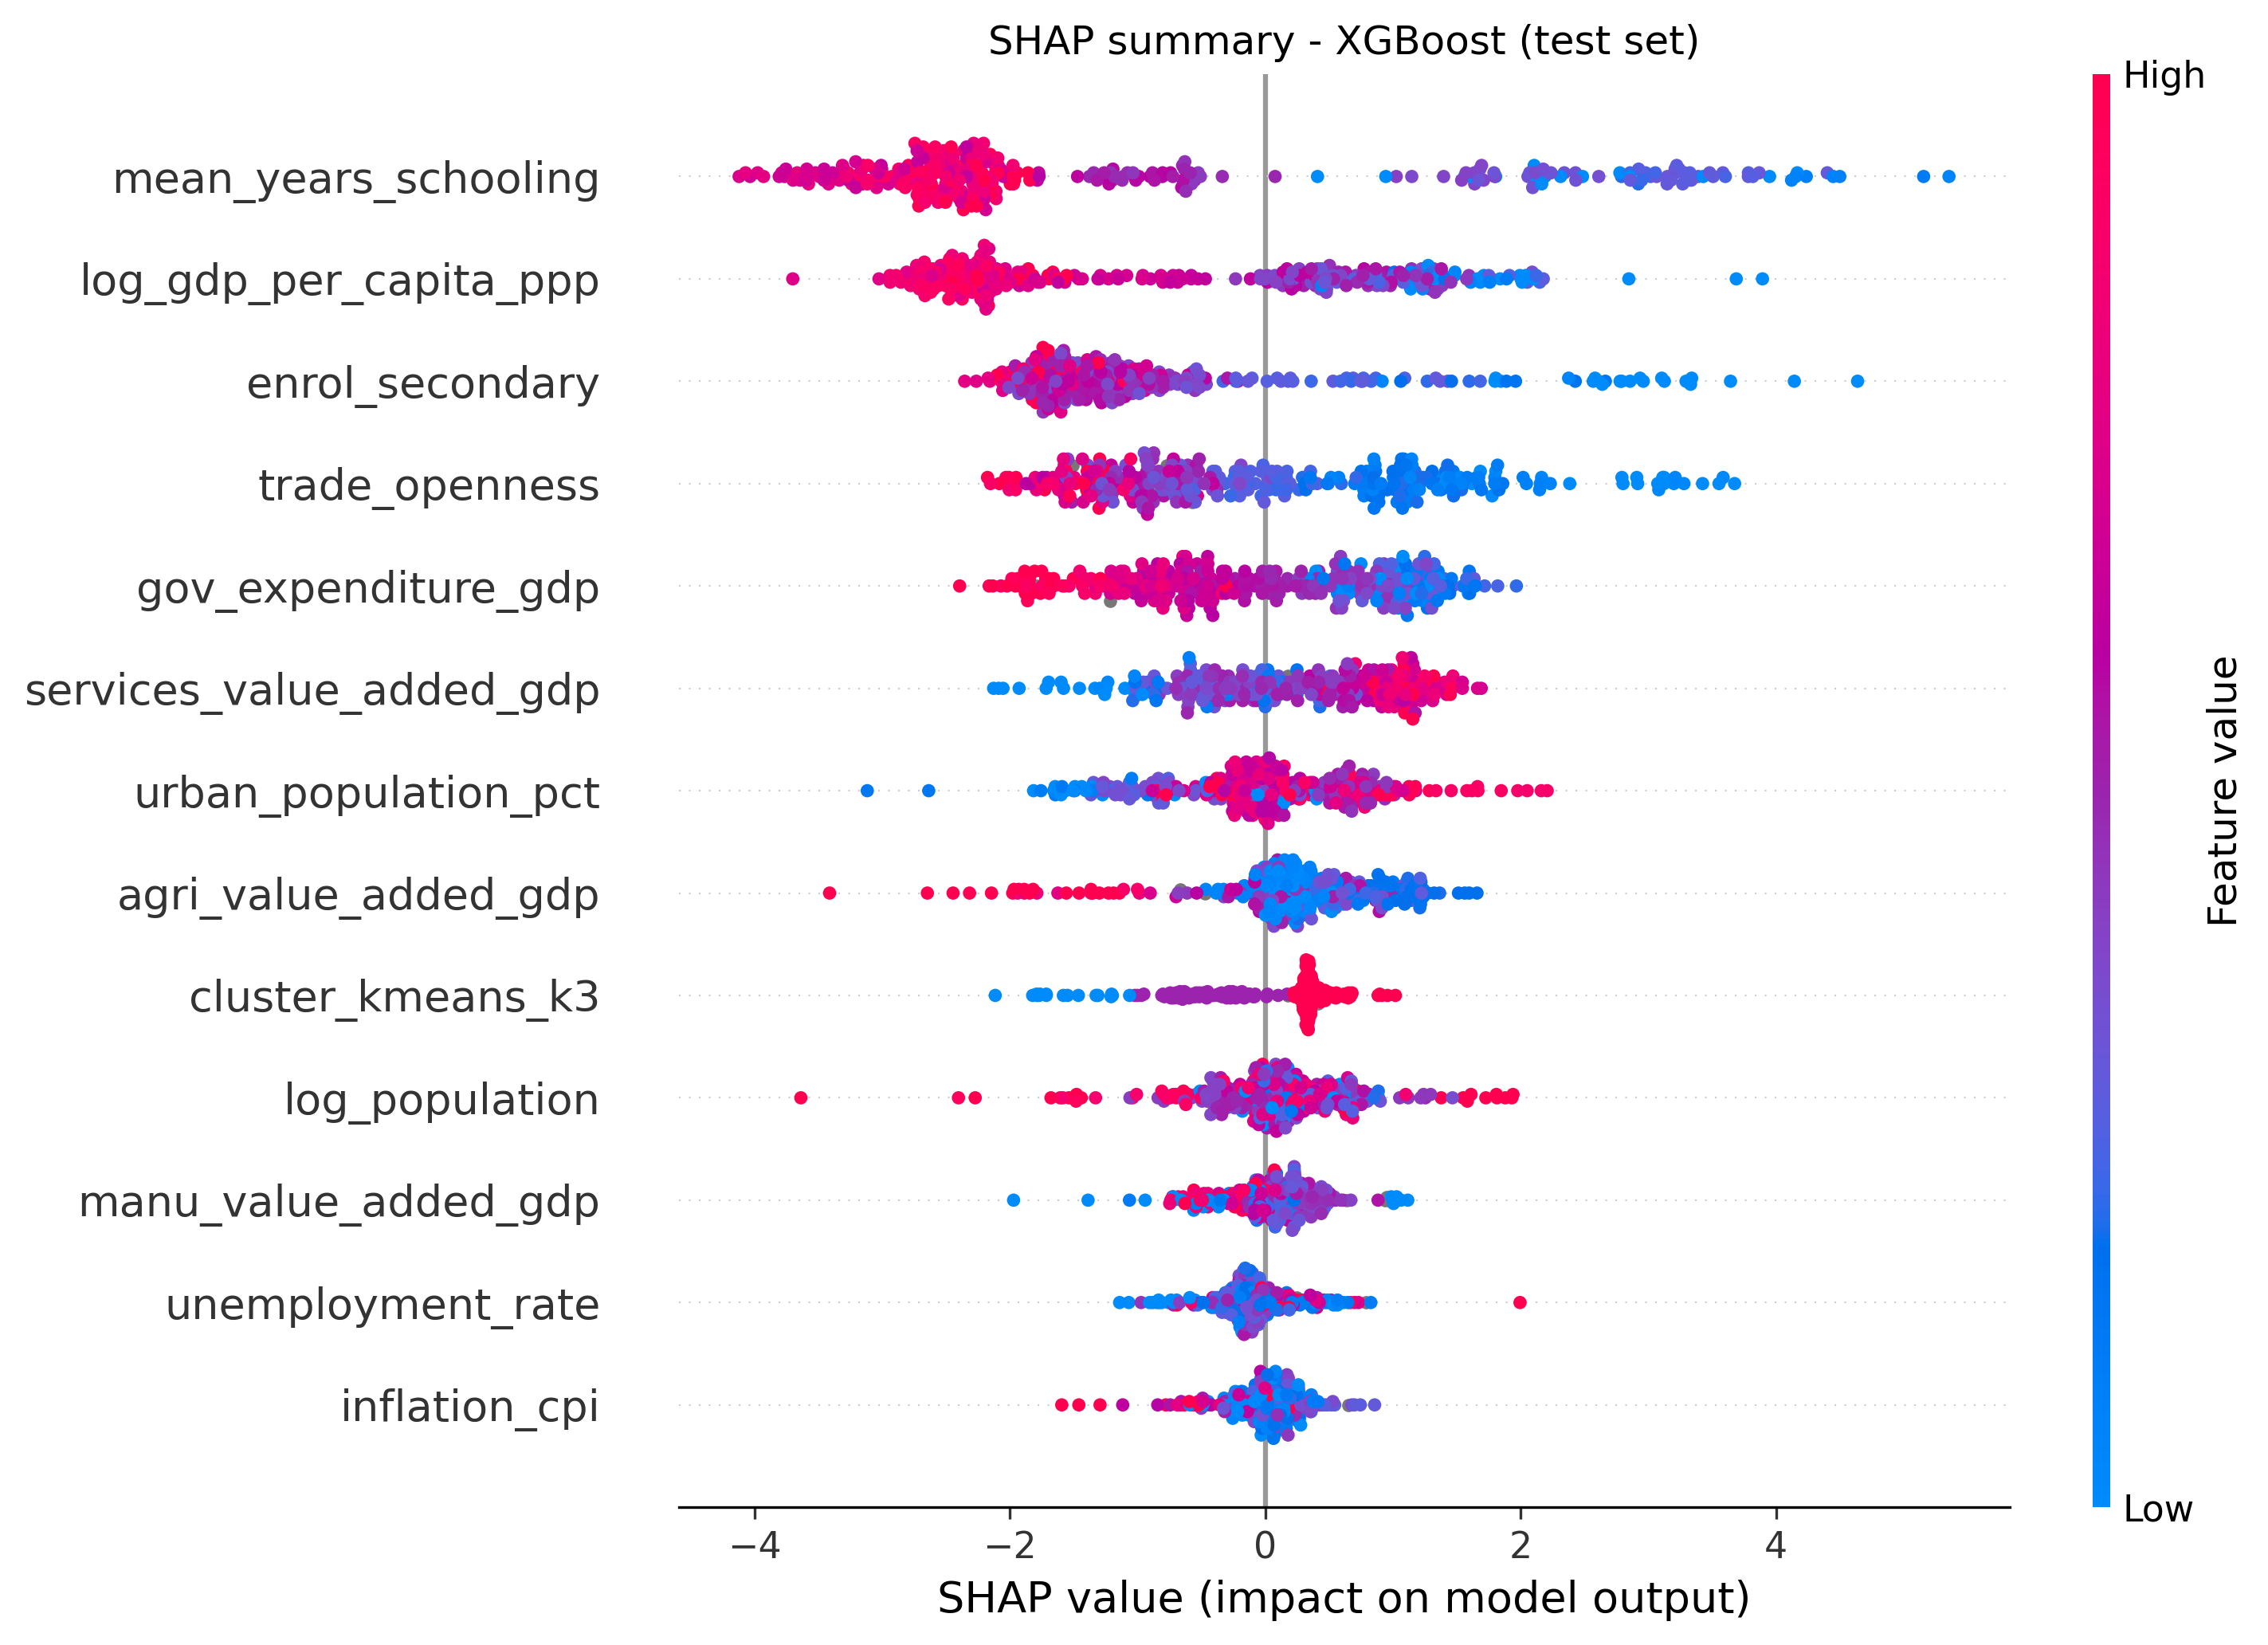

In [ ]:
Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase06_s06_shap_summary_xgb.png"))

**Explanation — Cluster 2 detection and aggregate SHAP magnitude.** Two
facts about the per-cluster SHAP results deserve attention. First, both ML
models detect a meaningful negative slope in Cluster 2 (mature economies)
where Phase 05 RE Spec C found none — interpretable as the linear panel
specification under-fitting the mature regime, with the saturated-schooling,
threshold-effect non-linearities being precisely what tree-based ensembles
can fit. Second, the aggregate mean signed SHAP magnitudes (−1.13, −1.06)
sit between the Phase 05 Pooled OLS point estimate (−1.33) and the Phase 05
RE point estimate (−0.69) — consistent with ML performing a
between-and-within mixed identification weighted toward the dominant
between-country signal. The Spearman ρ between the Phase 05 RE Spec A
absolute coefficient ranking and the Phase 06 mean |SHAP| ranking on the
five common features is +0.30 (p = 0.624) for both models; the mys-#1
agreement is robust, but the rest of the ranking is statistically unstable
on the Phase 05 side (4 of 5 RE Spec A coefficients have p ≥ 0.19), so
the rank disagreement below mys reflects Phase 05 sampling noise rather
than a methodological clash.

**Implication and the Phase 06 boundary-case caveat.** Phase 06 strengthens
the Cluster 1 finding from a single Phase 05 RE Spec C estimate of −1.19
to a chain of three independent estimates (−1.19 / −1.92 / −2.00) that
agree in direction and approximately in magnitude. The same phase produces
the project's most consequential internal caveat: when Brazil, South
Africa, Mexico, and Argentina are removed from training and used as a
59-country-year boundary-case holdout, both ML models produce test R² =
**−2.4** and the mean signed SHAP for mys flips to positive (+1.62 to
+2.46) for Brazil, South Africa, and Mexico — opposite to the in-sample
attribution. The full discussion of what this implies for causal inference
appears in §6.3.

## 6. Causal caveats: what would it take to claim causation?

Sections 2 through 5 documented a robust negative association between mean
years of schooling and the Gini coefficient that strengthens within the
Kuznets-transition cluster across three independent estimation strategies.
None of those sections claims that this association reflects a causal
effect. This section delineates *why* the analyses do not identify
causation and *what would have to be true* for a causal reading to be
defensible.

The four canonical threats to causal identification in observational
panels — omitted variable bias, reverse causality, measurement error, and
selection bias — are not independent boxes to be checked off. They
interact in this dataset in ways that strengthen the case against a causal
reading even where any one threat in isolation might seem manageable. The
discussion below threads the four threats through a single question:

> **Under what design assumptions could the Cluster 1 within-country slope
> of −1.19 (Phase 05 RE Spec C) to −2.00 (Phase 06 XGB SHAP-on-mys) be
> read as the causal effect of education on inequality?**

### 6.1 Omitted variables and reverse causality move together

The two-way fixed-effects specification absorbs *time-invariant* country
characteristics and *country-invariant* year shocks. It does not absorb a
third class of confounders: time-varying, country-specific factors that
move together with both education and inequality. Three plausible
candidates dominate this class:

- **Institutional quality** (rule of law, corruption control, fiscal
  capacity). Stronger institutions plausibly cause both higher educational
  attainment and lower inequality through redistribution and compliance —
  a textbook fork structure that biases the Pooled OLS coefficient
  downward (more negative than the causal effect) and that fixed effects
  cannot remove because institutional quality changes over time within
  country.

- **Conflict and political stability.** Civil conflict reduces school
  attainment and raises inequality contemporaneously; the listwise-excluded
  countries from Phase 04 (HTI, SOM, SSD, SYR, VEN, YEM, per Phase 04
  §Known Issues) make this concrete.

- **Health-system capacity.** Pandemics, child-mortality shocks, and
  nutrition deficits shape both schooling completion and labour-market
  sorting.

Reverse causality compounds the omitted-variable threat. Lower-inequality
societies have stronger political support for public-education investment;
they fund schools more generously; they retain teachers more easily. The
within-country covariation of mys and Gini is therefore consistent with
both directions of causation, and observational panel methods alone cannot
distinguish them. The Phase 05 FE Spec A point estimate (−0.38, p = 0.366)
is statistically null at the within-country aggregate level for exactly
this reason: identifying within-country variation strips out the dominant
between-country signal, and what remains is a noisy mixture of forward and
reverse causation contaminated by the time-varying confounders above.

### 6.2 Measurement error attenuates and selection bias compounds

Cross-country Gini coefficients in the World Bank's WDI series mix
consumption-based and income-based surveys, with some countries reporting
only one type and others switching mid-panel. Measurement error in the
dependent variable inflates standard errors but does not bias the slope
coefficient under classical assumptions. Measurement error in the
principal regressor — `mean_years_schooling`, sourced from UNDP HDR with
country-specific data-collection regimes — *does* bias the slope toward
zero (classical attenuation). The Phase 05 FE point estimate of −0.38 is
therefore consistent with both "no causal effect" and "a moderate causal
effect attenuated by measurement error". Phase 05 FE alone cannot tell
these apart.

Selection bias is the most consequential of the four threats in this
panel because of how Gini coverage is structured. The Phase 02 missingness
analysis identified Gini as the binding constraint at roughly 30 %
country-year completeness. Phase 05 Step 07 Check 3 quantified the
selection: the Gini-using sample is on average **+2.7 years more
educated, +0.7 log-units richer, and +9.8 percentage points more
urbanised** than the excluded country-years (all p < 0.001 country-year
level), with high-income countries over-represented in the *excluded*
sample (chi² = 17.29, df = 4, p = 0.0017 country-level). This is
plausibly Missing Not At Random: countries report Gini *because* they
have the statistical capacity to do so, and statistical capacity
correlates with both schooling and inequality. The headline coefficient
describes "countries with sustained Gini reporting", not the global
universe of 217 countries.

### 6.3 The boundary-case holdout is the strongest internal evidence

The four caveats above are general critiques applicable to any
observational cross-country panel. Phase 06 produced one robustness check
that converts these general concerns into a *specific* internal piece of
evidence: the boundary-case country holdout.

When Brazil, South Africa, Mexico, and Argentina are removed from training
and used as a 59-country-year out-of-sample evaluation set, both Random
Forest and XGBoost produce **test R² = −2.4** (worse than predicting the
training mean) and the mean signed SHAP for `mean_years_schooling` **flips
sign from negative to positive** for Brazil, South Africa, and Mexico
(range +1.62 to +2.46). The same trained model, evaluated on country-years
drawn from the same calendar window but on countries *not represented in
training*, produces predictions that are not just imprecise but
systematically wrong, and it does so by attributing the wrongness to mean
years of schooling — the very feature the in-sample SHAP attribution had
ranked first.

This is direct internal evidence that the Phase 06 SHAP attributions
reflect *within-distribution interpolation* rather than transportable
causal structure. A model that has learned the causal effect of mys on
Gini for Cluster 1 countries should be able to predict Brazil's Gini from
Brazil's mys, even if Brazil itself is not in the training set, because
the causal mechanism is general. A model that has learned a
within-Cluster-1-statistical-pattern should fail on Brazil for exactly the
reasons it does fail: Brazil's joint distribution of mys, GDP, and trade
openness sits in a region of feature space that the trained model has not
seen labels for.

### 6.4 What would need to be true for a causal reading

The chained Cluster 1 finding (Phase 05 RE Spec C −1.19, Phase 06 RF / XGB
SHAP-on-mys −1.92 / −2.00) is consistent with — but does not establish —
a causal effect of education expansion on inequality reduction in
middle-development economies. A causal reading would require at least
three additional pieces of identification that the project does not
currently provide:

1. **An exogenous source of variation in mys** that is independent of the
   time-varying confounders in §6.1 — typically a policy shock that varies
   across countries or sub-national units in a way uncorrelated with
   institutional quality, conflict, or health-system capacity.
   Compulsory-schooling reforms and discontinuities at policy thresholds
   are the standard candidates.

2. **A donor population that matches the treated unit's pre-treatment
   trajectory of Gini** so that the counterfactual is observable rather
   than assumed. The boundary-case finding tells us that Brazil / South
   Africa / Mexico are *exactly* the units for which a structurally
   grounded counterfactual matters most: the standard within-distribution
   machinery breaks on them.

3. **A measurement strategy that does not rely on Gini-reporting capacity
   as a selection filter.** Sub-national administrative data, in countries
   that produce sub-national Ginis, would be one route; consumption-based
   welfare measures from household surveys harmonised across countries
   would be another.

The project does not have these pieces. Section 7 outlines a follow-on
study designed to acquire them.

## 7. Identification strategies as future work

Four credible-identification strategies could in principle convert the
Cluster 1 association into a causal estimate. Each addresses a different
subset of the §6 caveats; none has been executed in this project.

| Strategy | Treats which caveat? | Data demand | Internal feasibility |
|---|---|---|---|
| **Synthetic control** on BRA / MEX / ZAF | §6.3 (boundary-case fragility) | Existing Phase 06 panel + policy-event timeline | High — Phase 06 directly identifies the treated units |
| **IV** via compulsory-schooling reforms | §6.1 (omitted variables) | Country-level reform-timing dataset | Medium — datasets exist in the development-economics literature; matching to current panel requires work |
| **RD** at policy thresholds | §6.1 (omitted variables) | Microdata from a single country with a sharp policy threshold | Low — out of cross-country scope |
| **DiD** around education-spending changes | §6.1 + §6.2 (timing of reverse causation) | Public-finance time series | Medium — World Bank / IMF data adequate, parallel-trends assumption testable |

The strategy specified in depth below is **synthetic control on Brazil,
Mexico, and South Africa**. The choice is forced by Phase 06: those three
countries are the units where the in-sample SHAP attribution has been
shown to fail, and synthetic control is designed exactly for the case
where an off-the-shelf comparison group does not produce a credible
counterfactual. The other three strategies are sketched briefly afterwards.

### 7.1 Synthetic control on BRA / MEX / ZAF — treatment definition

The synthetic control method, as developed by Abadie and co-authors,
constructs a counterfactual outcome path for each treated unit as a convex
combination of donor-pool units chosen to match the treated unit's
pre-treatment trajectory on the outcome and on a small set of
pre-treatment covariates. Three concrete treatment definitions are
candidates for this study:

- **Brazil**: the 1996 *Lei de Diretrizes e Bases da Educação Nacional*
  (LDB), which restructured federal-state coordination on education, and
  the contemporaneous FUNDEF redistributive funding mechanism (1998),
  later succeeded by FUNDEB (2007). Treatment year: **1996** or **1998**
  depending on whether the legal reform or the funding mechanism is the
  treatment of interest.

- **Mexico**: the 1992 *Acuerdo Nacional para la Modernización de la
  Educación Básica* (ANMEB) plus the *Ley General de Educación* of 1993,
  which decentralised basic education to states and expanded compulsory
  schooling. Treatment year: **1993**.

- **South Africa**: the 1996 *South African Schools Act* (SASA) and the
  contemporaneous post-apartheid education-funding overhaul. Treatment
  year: **1996**.

These three units share a structurally similar treatment (a major mid-1990s
national education-policy reform of comparable scope) but differ in
donor-pool implications: South Africa's apartheid-legacy starting condition
sits closer to the Cluster 0 / Cluster 1 boundary, while Brazil and Mexico
are squarely in Cluster 1 throughout the panel.

### 7.2 Synthetic control on BRA / MEX / ZAF — donor pool, pre-treatment fit, inference

**Donor pool.** Phase 04 Cluster 1 contains 59 countries. Removing the
three treated units (Brazil, Mexico, South Africa) leaves 56 candidate
donors. Argentina is the fourth Phase 06 boundary-case unit and would also
need to be excluded from the donor pool to avoid contamination from a
region of feature space the trained ML models demonstrably fail on. The
effective donor pool is therefore approximately **55 countries** —
adequate for a 1990-1995 pre-treatment matching window.

**Pre-treatment covariate matching.** The Phase 05 Spec A regressors
(`enrol_secondary`, `log(gdp_per_capita_ppp)`, `log(population)`,
`urban_population_pct`) supply the standard pre-treatment matching
variables. The pre-treatment outcome path (annual Gini values 1990-1995
for Brazil, 1990-1992 for Mexico, 1990-1995 for South Africa) constrains
the convex weights via the standard nested-optimisation routine.

**Inference.** Permutation tests via in-place placebo treatments —
assigning the treatment to each donor in turn and re-running the
synthetic control — generate the null distribution of post-treatment
outcome divergences. A treated unit's post-treatment Gini divergence is
"significant" if it exceeds the divergences of an appropriate share
(typically 90 % or 95 %) of placebo units. This is the standard inference
protocol; the more recent ridge-augmented synthetic control refinement
would be the appropriate implementation choice for cases where the
convex-weights solution is sparse or the pre-treatment fit is imperfect.

**Pre-registration of the design before any execution would be the
appropriate next step**, following the Phase 02-06 pre-registration
discipline used throughout this project.

### 7.3 IV, RD, and DiD as alternative routes

**Instrumental variables on compulsory-schooling reforms.** The standard
approach uses national reforms that change the minimum age of school
leaving as exogenous shocks to mean years of schooling within affected
birth cohorts. Adapting this approach to the country-year panel requires a
country-by-year dataset of compulsory-schooling laws; such datasets exist
in the development-economics literature. The instrument relevance
condition is well-established; the exclusion restriction (the reform
affects Gini *only* through its effect on mean years of schooling) is
harder to defend at the country level because the same political
coalitions that pass schooling reforms tend to pass redistributive reforms
in the same period.

**Regression discontinuity at policy thresholds.** Sharp RD is the
gold-standard internal-validity design for policy thresholds (e.g.,
scholarship cutoffs, district-funding formula breaks). It is difficult to
apply at the cross-country aggregate because few cross-country thresholds
are sharp enough. RD is more naturally a within-country sub-national
analysis using administrative microdata; this falls outside the
cross-country panel scope of the present project but is a viable
extension for any single Cluster 1 country with a clean threshold.

**Difference-in-differences around education-spending changes.**
Country-year changes in the public education-spending share of GDP, used
as a treatment, allow a DiD design with parallel-trends inspection. The
Phase 05 Spec B regressor `gov_expenditure_gdp` is the relevant series;
the limitation is that policy-driven spending changes are typically also
responses to inequality, re-introducing reverse causality. Event studies
around discrete spending-rule changes (e.g., constitutional earmarks) are
the cleanest DiD specification.

### 7.4 Why synthetic control is the natural follow-up

Of the four strategies above, synthetic control on Brazil, Mexico, and
South Africa is the natural follow-on study to *this* project specifically —
not because it is the most credible identification strategy in the
abstract, but because it is the strategy that uses Phase 06's most
distinctive caveat as its motivating evidence.

Phase 06 produced a holdout finding that two flexible non-parametric
models trained on 56 + Cluster 1 countries fail when asked to predict the
three treated units. Synthetic control acknowledges that failure
structurally: instead of asking a model to learn a transferable function,
it constructs a country-specific counterfactual built explicitly from a
donor pool whose pre-treatment trajectory matches each treated unit. The
boundary-case caveat is therefore not just a methodological footnote in
this project; it is the empirical justification for the next study's
design choice.

The remaining three strategies (IV / RD / DiD) operate at higher levels of
abstraction relative to the data this project has assembled. Synthetic
control sits closest to the existing infrastructure: same panel, same
outcome, same analytical sample, with the donor-pool selection and
treatment-event timing as the only new design ingredients.

## 8. Policy implications — conditional on causation

This project has not identified a causal effect of education on inequality.
Section 6 explained why; Section 7 described what credible identification
would require. **Any policy implication drawn from this project's findings
is therefore *conditional* on a causal reading that the project does not,
on its own evidence, justify.**

The discussion below adopts the explicit conditional form: "*if* the
Cluster 1 within-country slope reflected a causal effect, *then* the
implied theory of change would be...". This framing is not pro forma. It
is the only language consistent with §6 above and with the boundary-case
evidence in §6.3. Readers who treat the conditional as a hidden
unconditional are reading the project against its evidence base.

Cluster 1 — the middle-development / Kuznets-transition cluster — is the
only stratum where the within-country slope is statistically detectable in
Phase 05 (RE Spec C −1.19, p = 0.010) and substantively large in Phase 06
(RF / XGB SHAP-on-mys −1.92 / −2.00). Clusters 0 and 2 are excluded from
the conditional policy framing for reasons given in §8.2.

### 8.1 Cluster 1 — conditional theory of change

If the Cluster 1 within-country slope of approximately −1.2 to −2.0
Gini-points per additional mys-year were causal, the implied theory of
change would be:

- **In countries with mean years of schooling around 8-9 and Gini around
  38-41**, expanding the average level of educational attainment by one
  year would compress the income distribution by between roughly 1 and 2
  Gini points within the same country over the panel time horizon
  (roughly two to three decades).

- The mechanism most consistent with the magnitude is **labour-market
  sorting**: as the marginal worker enters secondary or post-secondary
  tracks, the wage premium on completed secondary schooling falls,
  compressing the inter-decile spread that dominates Gini in middle-income
  economies.

- The implied policy levers are **secondary-school completion rates,
  vocational pathway access, and the relative supply of upper-secondary
  graduates** rather than tertiary expansion or primary enrolment, both of
  which are nearly saturated or already mass in this cluster.

The magnitude of the implied effect is non-trivial: Phase 04 Cluster 1
mean Gini is 39.05; a 2-point reduction would shift the cluster mean
toward 37, comparable to the present-day Cluster 1 / Cluster 2 boundary.
The empirical question of whether the within-country slope in Cluster 1 is
in fact causal is exactly the question §7's synthetic-control follow-up
is designed to address.

### 8.2 Why Clusters 0 and 2 are excluded from policy framing

**Cluster 0** (low-development, mean Gini 38.24, mean mys 4.22) has a
Phase 05 RE Spec C within-country slope of −0.80 (p = 0.13) — the point
estimate is negative and of similar magnitude to Cluster 1, but the
variance is too large to distinguish from zero on the available
within-country variation. The likely substantive reason is that the
cluster contains too few country-years with meaningful schooling expansion
to identify the relationship: mys variation within Cluster 0 is small
because most countries in this cluster are below the threshold where mass
secondary expansion has begun.

**Cluster 2** (mature economies, mean Gini 34.72, mean mys 11.36) has a
Phase 05 RE Spec C within-country slope of −0.33 (p = 0.42) — point
estimate negative but small, and statistically null. The substantive
reason here is the opposite of Cluster 0: schooling is near-saturated, the
marginal year of mys reflects post-secondary or tertiary expansion, and
the empirical relationship between *additional* tertiary access and
inequality is theoretically ambiguous (it can compress or widen the wage
distribution depending on the supply elasticity of skilled labour).

Phase 06's predictive layer detects a meaningful negative SHAP-slope in
Cluster 2 (RF −0.84, XGB −0.85) where Phase 05 finds none — interpretable
as Phase 05's linear specification under-fitting the mature regime — but
the magnitude is half the Cluster 1 finding and the substantive
interpretation remains contested. The honest position is that this
project does not have the evidence to write policy implications for
Clusters 0 or 2; doing so would extend the conditional framing in §8.1
onto strata where the underlying empirical association is itself fragile.

## 9. Structural limitations and research agenda

### 9.1 Structural limitations carried forward from earlier phases

Several limitations are intrinsic to the dataset, the design choices made
in Phases 01-02, and the panel-econometric / ML-explainability methods
used in Phases 05-06. None of these are individually fatal; collectively
they delineate the population to which the project's findings apply.

- **MNAR selection on Gini reporting.** Per §6.2 above, the analytical
  sample is the 153-country, 1,642-country-year subset that has at least
  one Gini observation under the Spec A row criterion. Phase 04's
  listwise drop (50 countries) and the country-level chi-squared
  (p = 0.0017) make the selection structure concrete. The headline
  finding therefore generalises to "countries with sustained Gini
  reporting and adequate covariate coverage", not to all 217 World Bank
  countries.

- **Cross-country Gini measurement heterogeneity.** Consumption-based and
  income-based Gini surveys are mixed across the panel. Within-country
  identification (Phase 05 FE; Phase 06 SHAP-on-mys per cluster) is
  partially insulated against the cross-method differences when a
  country's reporting regime is stable, but the cross-cluster magnitude
  comparisons are not. A robust extension would harmonise the Gini series
  via the LIS or WID consumption / income concordances.

- **Country-level aggregation.** All Phase 05 and Phase 06 estimates are
  at the country-year level. Sub-national heterogeneity within Brazil,
  India, China, Indonesia, and the United States is meaningful for
  inequality but is averaged out at the national level. A natural
  follow-up — independent of the synthetic-control study in §7 — is to
  repeat the Cluster 1 analysis on sub-national administrative microdata
  for the three countries (Brazil, Mexico, South Africa) where such data
  exist.

- **Temporal extrapolation cost.** The Phase 06 TimeSeriesSplit minus
  random-KFold RMSE gap (+0.41 to +0.60) reflects a structural difficulty
  inherent to year-out-of-sample prediction on panel data. The trained
  ML models are calibrated to produce reasonable predictions for the
  panel's covered years; extrapolating to post-2023 country-years
  introduces a known degradation that cannot be fixed within the existing
  sample window.

- **Pre-2000 enrolment data sparsity.** The Phase 04 cluster construction
  window of 2010-2019 (after the Step 02b adaptation) avoids the pre-2000
  sparsity by design, but any retroactive analysis using earlier years
  inherits the sparseness. The Cluster 1 finding is most robustly
  identified within the 2000-2019 portion of the panel.

### 9.2 Research agenda

The natural follow-on programme has three components, ordered by empirical
proximity to the present project.

1. **Synthetic control on Brazil, Mexico, and South Africa** as detailed
   in §7.1-7.2. This is the single most defensible next study because it
   uses the present project's most distinctive internal caveat (the
   Phase 06 boundary-case holdout) as its motivating evidence and
   operates on the same panel infrastructure with no new data acquisition.

2. **Sub-national replication of the Cluster 1 finding** in the same
   three countries using national household-survey microdata (PNAD for
   Brazil, ENIGH for Mexico, GHS / IES for South Africa). This converts
   the within-country variation that Phase 05 FE found inadequate at the
   country-year level into within-country, within-period variation
   across sub-national units, where the schooling-inequality channel is
   directly observable.

3. **IV implementation using compulsory-schooling reform timing**,
   building from the country-year reform-event datasets available in the
   development-economics literature. This addresses the §6.1
   omitted-variable threat that synthetic control (designed for the §6.3
   boundary-case fragility) does not directly target, and is therefore
   complementary rather than duplicative.

The three components, taken together, would address the four §6 caveats:
synthetic control addresses §6.3 (boundary-case fragility), sub-national
replication addresses §6.2 (selection on Gini reporting and aggregation
bias), and the IV component addresses §6.1 (omitted variables and reverse
causality).

### 9.3 What this project found, and what it does not claim

This project documented a robust negative association between mean years
of schooling and the Gini coefficient in cross-country panel data
1990-2023. The association is strongest, most precisely estimated, and
methodologically most robust within the 59-country middle-development /
Kuznets-transition cluster identified by Phase 04 K-means clustering. The
cluster-specific within-country slope is approximately −1.2 to −2.0
Gini-points per additional year of mean schooling, with the magnitude
depending on the estimator and being roughly 1.7 × larger under Phase 06's
flexible tree-based ML attribution than under Phase 05's linear panel RE
Spec C.

The project does not claim that this association reflects a causal effect
of education on inequality. The four §6 caveats — omitted variables,
reverse causality, measurement error, and selection bias from
Gini-reporting — interact in ways that observational panel methods cannot
resolve, and the Phase 06 boundary-case holdout provides direct internal
evidence that the in-sample attribution is within-distribution
interpolation rather than transportable causal structure.

What the project does provide is a clean *within-Gini-reporting-population*
characterisation of the education-inequality association, a country-level
typology in which the association is heterogeneous and concentrated in the
Kuznets-transition middle, and a research agenda built around the specific
identification strategies most directly motivated by the project's own
internal evidence. The closing question — *what would it take to claim
more?* — is answered: synthetic control on the boundary-case three,
sub-national replication, and a compulsory-schooling-reform IV. None of
those is in this project; each is grounded in evidence this project
produced.

---

*End of notebook 07. Project closes at v1.0 with the phase wrap in
Step 06.*